In [1]:
import matplotlib.pyplot as plt
import numpy as np
import configparser
from scipy import stats
from sklearn.metrics import roc_curve, auc

In [2]:
#pmt details
!curl -O https://raw.githubusercontent.com/XENON1T/pax/refs/heads/master/pax/config/XENON1T.ini
config = configparser.ConfigParser()
config.read('XENON1T.ini')
pmt_config = eval(config['DEFAULT']['pmts'])
pmt_positions = np.array([(x['position']['x'], x['position']['y'])
                           for x in pmt_config if x.get('array', '') == 'top'])
tpc_radius = 47.9

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100 303.3k 100 303.3k   0      0  1.15M      0                              0
100 303.3k 100 303.3k   0      0  1.15M      0                              0
100 303.3k 100 303.3k   0      0  1.15M      0                              0


In [3]:
def mean_response(xy):
    """Return normalized mean response of PMTs to light emission at xy"""
    a = -2.7e-5
    b = 3.6e-3
    i0 = 0.290
    d = 12.13
    p = 2.35
    # Compute distance from xy to pmt position
    # xy has shape (positions, 2)
    # pmt_positions has shape (pmts, 2)
    # Output should have shape (positions, pmts)
    rho = np.linalg.norm(xy[:, None, :] - pmt_positions[None, :, :], axis=2)
    raw_lce = i0 * (1-b) / (1 + (rho/d)**2)**p + a * rho + b
    # Normalize to 1
    return raw_lce / np.sum(raw_lce, axis=1)[:, None]

def simulate_signal(xy, photons=10_000):
    """Simulate a signal where an average number of photons are detected by PMTs at xy"""
    lce = mean_response(xy)
    # Random photon detection
    photons_detected = np.random.poisson(photons * lce)
    # Double photoelectron emission
    pe_detected = photons_detected + np.random.binomial(photons_detected, 0.2)
    # Gaussian smearing
    return np.random.normal(pe_detected, 0.3 * np.sqrt(pe_detected))

    
print(simulate_signal(np.array([[0, 0]]), photons=30).sum(axis=0))


[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         1.2865417  0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         1.29936304 0.         1.06314075 0.         1.09316536
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         1.06561983 0.         1.48355803
 0.         0.         0.         0.         0.         0.
 0.         1.86313462 0.         0.         0.         0.
 0.         0.         0.         1.0742

In [4]:
def loss_function(xy, signal):
    """Negative log-likelihood of observing signal given mean response at xy. The log likelihood is defined as the sum of the log of the Poisson probabilities for each PMT, given the expected signal from the mean response at xy."""
    lce = mean_response(xy.reshape(1, 2)).squeeze()
    expected_signal = 10_000 * lce  # Assuming 10k photons emitted
    # Poisson likelihood
    return -np.sum(signal * np.log(expected_signal + 1e-6) - expected_signal)

[ 2.68195334 -0.42050232]


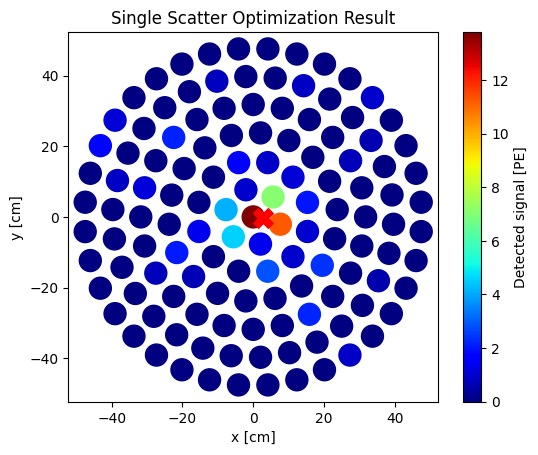

In [5]:
from scipy.optimize import minimize
# Single scatter optimizer
def single_scatter_optimizer(signal):
    """Optimizes parameters for single scatter hypothesis,
    taking the highest valued pmt as initial guess and
    then running a local optimizer"""

    pmt_high=np.argmax(signal)
    initial_guess = pmt_positions[pmt_high]
    result = minimize(lambda xy: loss_function(xy, signal), initial_guess, bounds=[(-tpc_radius, tpc_radius), (-tpc_radius, tpc_radius)])
    return result.x

#with plotting of pmt array
def single_scatter_optimizer_with_plotting(signal):
    """Optimizes parameters for single scatter hypothesis,
    taking the highest valued pmt as initial guess and
    then running a local optimizer, with plotting of the PMT array and the optimization result"""

    pmt_high=np.argmax(signal)
    initial_guess = pmt_positions[pmt_high]
    result = minimize(lambda xy: loss_function(xy, signal), initial_guess, bounds=[(-tpc_radius, tpc_radius), (-tpc_radius, tpc_radius)])
    print(result.x)

    # Plotting
    plt.scatter(*pmt_positions.T, c=signal, cmap='jet', s=250, vmin=0)
    plt.colorbar(label='Detected signal [PE]')
    plt.scatter(*result.x, c='red', marker='X', s=200, label='Optimized Position')
    plt.gca().set_aspect('equal')
    plt.xlabel('x [cm]')
    plt.ylabel('y [cm]')

    plt.title('Single Scatter Optimization Result')
    plt.show()

single_scatter_optimizer_with_plotting(simulate_signal(np.array([[0, 0], [5, 0]]), photons=30).sum(axis=0))

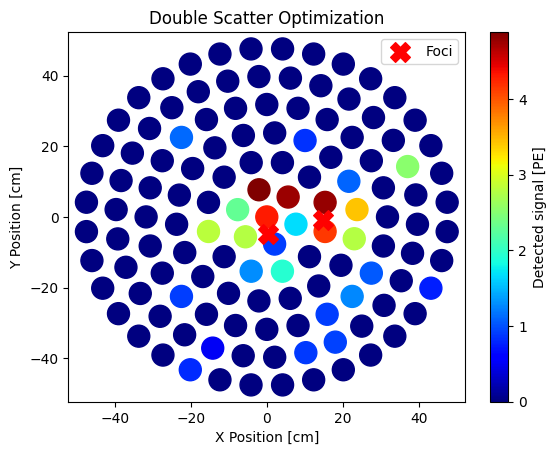

(array([ 0.43339172, -4.85097125, 14.71165144, -0.87816283,  0.5       ]),
 (0.4333915716990626, -4.850971618408693),
 (14.711651207498424, -0.8781633475839885))

In [45]:
#double scatter optimizer
def double_scatter_initial_guess(signal):
    """Optimizes parameters for double scatter hypothesis, using ellipse foci and 50/50 split of signal as initial guess,
    with plotting of the PMT array and the optimization result. That means varying 5 parameters: x1, y1, x2, y2, and the split ratio of the signal between the two scatters.
    """
    # 2D weighted covariance matrix
    weights = signal / signal.sum()
    x_mean = np.sum(weights * pmt_positions[:, 0])
    y_mean = np.sum(weights * pmt_positions[:, 1])

    dx = pmt_positions[:, 0] - x_mean
    dy = pmt_positions[:, 1] - y_mean

    cov_xx = np.sum(weights * dx**2)
    cov_yy = np.sum(weights * dy**2)
    cov_xy = np.sum(weights * dx * dy)

    cov = np.array([[cov_xx, cov_xy],
                [cov_xy, cov_yy]])

    #Eigendecomposition gives the ellipse axes and rotation
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Semi-axes are sqrt of eigenvalues, angle from principal eigenvector
    a = np.sqrt(eigenvalues[1])  # semi-major
    b = np.sqrt(eigenvalues[0])  # semi-minor
    angle_deg = np.degrees(np.arctan2(eigenvectors[1, 1], eigenvectors[0, 1]))

    # Foci lie along the major axis at distance c from center
    c = np.sqrt(a**2 - b**2)
    major_axis = eigenvectors[:, 1]  # principal eigenvector
    focus1 = (x_mean + c * major_axis[0], y_mean + c * major_axis[1])
    focus2 = (x_mean - c * major_axis[0], y_mean - c * major_axis[1])
    initial_guess = [focus1[0], focus1[1], focus2[0], focus2[1], 0.5]  # x1, y1, x2, y2, split ratio

    return initial_guess, focus1, focus2, (x_mean, y_mean), a, b, angle_deg

def double_scatter_loss(params, signal):
    x1, y1, x2, y2, split_ratio = [float(p) for p in params]
    xy1 = np.array([[x1, y1]])
    xy2 = np.array([[x2, y2]])
    signal1 = simulate_signal(xy1, photons=int(10_000 * split_ratio)).sum(axis=0)
    signal2 = simulate_signal(xy2, photons=int(10_000 * (1 - split_ratio))).sum(axis=0)
    combined_signal = signal1 + signal2
    return loss_function(np.array([[x1, y1]]), combined_signal) + loss_function(np.array([[x2, y2]]), combined_signal)

def double_scatter_optimizer(signal):
    initial_guess, focus1, focus2, (x_mean, y_mean), a, b, angle_deg = double_scatter_initial_guess(signal)

    result = minimize(double_scatter_loss, initial_guess, args=(signal,),
                      bounds=[(-tpc_radius, tpc_radius), (-tpc_radius, tpc_radius),
                               (-tpc_radius, tpc_radius), (-tpc_radius, tpc_radius),
                               (0.01, 0.99)])
    
    #plotting ellipse, foci, optimized positions
    plt.scatter(*pmt_positions.T, c=signal, cmap='jet', s=250, vmin=0)
    plt.colorbar(label='Detected signal [PE]')
    plt.scatter([focus1[0], focus2[0]], [focus1[1], focus2[1]], c='red', marker='X', s=200, label='Foci')
    plt.legend()
    plt.title('Double Scatter Optimization')
    plt.xlabel('X Position [cm]')
    plt.ylabel('Y Position [cm]')
    #t = np.linspace(0, 2 * np.pi, 100)
    #ellipse_x = x_mean + a * np.cos(t) * np.cos(np.radians(angle_deg)) - b * np.sin(t) * np.sin(np.radians(angle_deg))
    #ellipse_y = y_mean + a * np.cos(t) * np.sin(np.radians(angle_deg)) + b * np.sin(t) * np.cos(np.radians(angle_deg))
    #plt.plot(ellipse_x, ellipse_y, c='red', label='Covariance Ellipse')
    plt.legend()
    plt.show()
    return result.x, focus1, focus2

double_scatter_optimizer(simulate_signal(np.array([[0, 0], [20, 0]]), photons=30).sum(axis=0))
